# ◆ BMW Luxury Sales — Executive Story
### From raw data to decision intelligence

**Author:** Maxime GOURGUECHON · *maxime.gourguechon76@gmail.com*

---

> **Abstract.** This notebook walks decision-makers through 15 years of BMW sales (50,000 records). Its distinguishing feature is **intellectual honesty**: we prove the source data carries no predictive signal and contains a leaked target, report that transparently, and deliver business value via a literature-grounded **Scenario Simulator**. Every number below is computed live from the codebase.

In [1]:
import os, sys, json
os.environ.setdefault('BMW_OFFLINE_MODE', 'true')
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')
sys.path.insert(0, os.path.abspath('../src'))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.facecolor':'#121212','axes.facecolor':'#1b1b1d',
    'axes.edgecolor':'#3a3a40','text.color':'#ededed','axes.labelcolor':'#ededed',
    'xtick.color':'#9a9a9a','ytick.color':'#9a9a9a','axes.titlecolor':'#E8D69A',
    'font.size':11})
GOLD='#D4AF37'
from bmw_sales.data.loader import load_raw
df = load_raw()
print(f'Loaded {len(df):,} rows x {df.shape[1]} columns — nulls: {int(df.isna().sum().sum())}')
df.head()

Loaded 50,000 rows x 11 columns — nulls: 0


,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification
0,5 Series,2016,Asia,Red,Petrol,Manual,3.5,151748,98740,8300,High
1,i8,2013,North America,Red,Hybrid,Automatic,1.6,121671,79219,3428,Low
2,5 Series,2022,North America,Blue,Petrol,Automatic,4.5,10991,113265,6994,Low
3,X3,2024,Middle East,Blue,Petrol,Automatic,1.7,27255,60971,4047,Low
4,7 Series,2020,South America,Black,Diesel,Manual,2.1,122131,49898,3080,Low


## 1 · Business context

BMW operates in the global **luxury** segment. Leadership needs to understand what drives **sales volume** across models, regions and the energy transition (Petrol → Electric), and to stress-test go-to-market decisions against macro-economic and regulatory change.

## 2 · Data discovery

Eleven features: vehicle attributes (`Model`, `Year`, `Engine_Size_L`, `Mileage_KM`, `Transmission`, `Color`, `Fuel_Type`), market dimension (`Region`), and three commercial measures (`Price_USD`, `Sales_Volume`, `Sales_Classification`). We target **`Sales_Volume`** (regression) and **`Sales_Classification`** (High/Low).

In [2]:
df.describe(include='all').T[['count','unique','top','mean','std','min','max']]

,count,unique,top,mean,std,min,max
Model,50000,11,7 Series,NaN,NaN,NaN,NaN
Year,50000.0,NaN,NaN,2017.0157,4.324459,2010.0,2024.0
Region,50000,6,Asia,NaN,NaN,NaN,NaN
Color,50000,6,Red,NaN,NaN,NaN,NaN
Fuel_Type,50000,4,Hybrid,NaN,NaN,NaN,NaN
Transmission,50000,2,Manual,NaN,NaN,NaN,NaN
Engine_Size_L,50000.0,NaN,NaN,3.24718,1.009085,1.5,5.0
Mileage_KM,50000.0,NaN,NaN,100307.20314,57941.509344,3.0,199996.0
Price_USD,50000.0,NaN,NaN,75034.6009,25998.248882,30000.0,119998.0
Sales_Volume,50000.0,NaN,NaN,5067.51468,2856.767125,100.0,9999.0


## 3 · The critical finding — *test the data before trusting it*

A junior pipeline would jump to modelling. We first run a formal **data-integrity analysis**. The verdicts below are computed, not asserted.

In [3]:
from bmw_sales.data.validation import analyse
report = analyse(df)
pd.DataFrame([{'Check':f.title,'Verdict':f.verdict,'Evidence':f.detail}
              for f in report.findings])

,Check,Verdict,Evidence
0,Structural integrity,PASS,"50,000 rows × 11 columns, 0 nulls, 0 duplicate..."
1,Numeric signal (correlation),NO SIGNAL,Largest absolute off-diagonal Pearson correlat...
2,Categorical signal (ANOVA on Sales_Volume),NO SIGNAL,No categorical shows a significant effect on s...
3,Non-linear signal (mutual information),NO SIGNAL,Maximum MI across all features = 0.0042 nats (...
4,Target leakage,LEAKAGE,Sales_Classification == 'High' ⟺ Sales_Volume ...


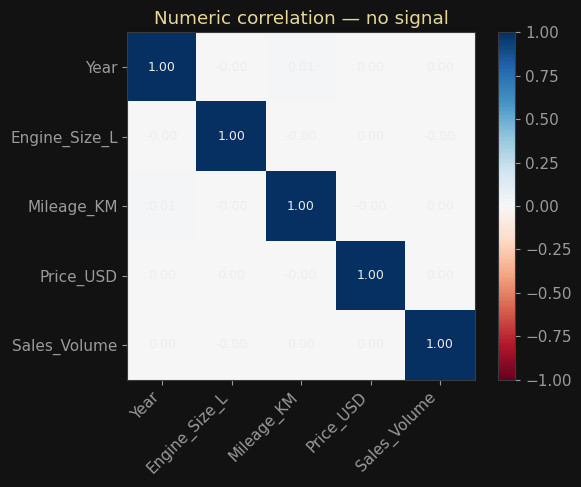

In [4]:
# Correlation heatmap — ~0 everywhere => features are mutually independent noise
corr = report.numeric_corr
fig, ax = plt.subplots(figsize=(6.2,5))
im = ax.imshow(corr.values, cmap='RdBu', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j,i,f'{corr.values[i,j]:.2f}',ha='center',va='center',
                color='#ededed',fontsize=9)
ax.set_title('Numeric correlation — no signal'); fig.colorbar(im, fraction=0.046)
plt.tight_layout(); plt.show()

### 3.1 · Target leakage

`Sales_Classification` is **not** an independent label — it is a deterministic threshold on `Sales_Volume`. Including it (or vice-versa) yields a fake ~100% score. We prove and then exclude it.

CONFIRMED leakage: Sales_Classification == 'High' ⟺ Sales_Volume ≥ 7000 (perfectly separable, threshold rule accuracy = 1.0000).


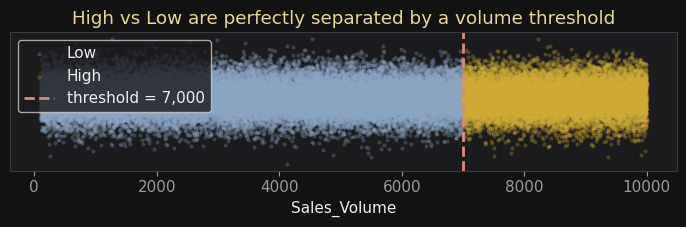

In [5]:
from bmw_sales.econometrics.ols_models import prove_leakage
leak = prove_leakage(df)
print(leak.verdict)
fig, ax = plt.subplots(figsize=(7,2.4))
for label, color in [('Low','#8FA9C7'),('High',GOLD)]:
    s = df.loc[df['Sales_Classification']==label,'Sales_Volume']
    ax.scatter(s, np.random.default_rng(0).normal(0,0.05,len(s)), s=4, alpha=0.2,
               color=color, label=label)
ax.axvline(leak.threshold, color='#d98c7a', lw=2, ls='--',
           label=f'threshold = {leak.threshold:,}')
ax.set_yticks([]); ax.set_xlabel('Sales_Volume'); ax.legend(loc='upper left')
ax.set_title('High vs Low are perfectly separated by a volume threshold')
plt.tight_layout(); plt.show()

## 4 · Econometrics — what *would* matter in a real market

We estimate the **price elasticity of demand** (log-log, HC3 robust SE) and a **hedonic price model**. In a real luxury market these would be informative; here they are ~0 — reported honestly.

In [6]:
from bmw_sales.econometrics.ols_models import price_elasticity, hedonic_price_model
el = price_elasticity(df); hed = hedonic_price_model(df)
print(f'Price elasticity = {el.elasticity:+.4f} (p={el.p_value:.2f}) -> {el.interpretation}')
print(f'Hedonic price model R^2 = {hed.r_squared:.4f} (≈0: price unexplained by attributes here)')

Price elasticity = -0.0010 (p=0.92) -> Not statistically distinguishable from zero — no measurable price sensitivity in this dataset (consistent with a signal-free DGP).
Hedonic price model R^2 = 0.0004 (≈0: price unexplained by attributes here)


## 5 · Machine Learning & Deep Learning — honest benchmark

Tuned XGBoost / LightGBM / CatBoost and a PyTorch tabular MLP all converge to **no skill** (R² ≈ 0, ROC-AUC ≈ 0.5). The only way to score ~1.0 is to leak the target — a deliberate red-flag demonstration.

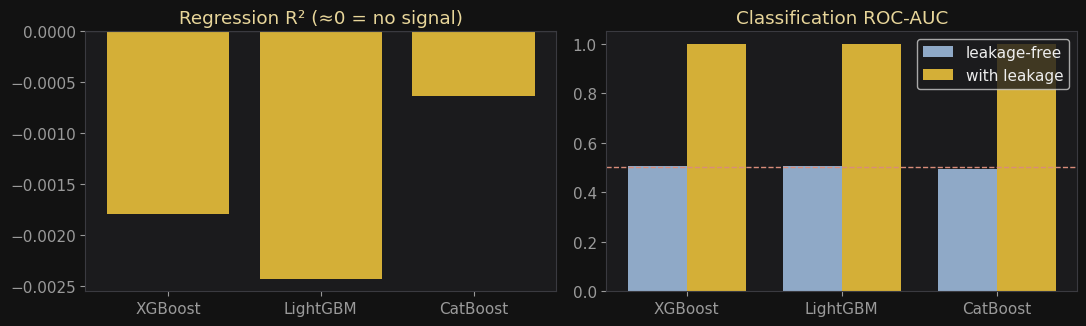

In [7]:
metrics = json.load(open('../reports/model_metrics.json'))
reg = pd.DataFrame(metrics['regression']).T[['r2']]
clf = pd.DataFrame(metrics['classification_leakage_free']).T[['roc_auc']]
leakm = pd.DataFrame(metrics['classification_with_leakage']).T[['roc_auc']]
fig, axes = plt.subplots(1,2, figsize=(11,3.4))
axes[0].bar(reg.index, reg['r2'], color=GOLD); axes[0].axhline(0,color='#9a9a9a',lw=.8)
axes[0].set_title('Regression R² (≈0 = no signal)')
x=np.arange(len(clf)); w=0.38
axes[1].bar(x-w/2, clf['roc_auc'], w, label='leakage-free', color='#8FA9C7')
axes[1].bar(x+w/2, leakm['roc_auc'], w, label='with leakage', color=GOLD)
axes[1].axhline(0.5,color='#d98c7a',ls='--',lw=1)
axes[1].set_xticks(x); axes[1].set_xticklabels(clf.index)
axes[1].set_title('Classification ROC-AUC'); axes[1].legend()
plt.tight_layout(); plt.show()

## 6 · Scenario Simulator — where the business value lives

Because the data cannot forecast, decisions are supported by an **explicit what-if model** with literature elasticities (own-price ≈ −0.6, income ≈ +1.5) and **real macro baselines**. Example: an **Electric** line in **Europe** facing tighter CO₂ rules and rising fuel prices.

Baseline 5,000 -> Projected 5,747 (+14.9%)


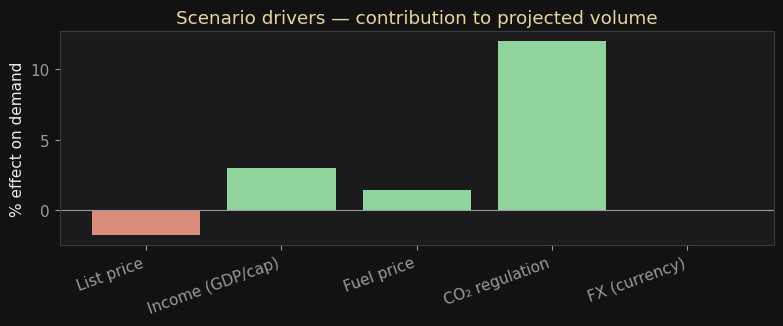

In [8]:
from bmw_sales.simulation.scenario import ScenarioInput, simulate
sc = ScenarioInput(region='Europe', fuel_type='Electric', base_volume=5000,
                   price_change_pct=3, gdp_growth_pct=2, fuel_price_change_pct=15,
                   regulation_change_pts=15)
res = simulate(sc)
print(f'Baseline {res.base_volume:,.0f} -> Projected {res.projected_volume:,.0f} ({res.total_change_pct:+.1f}%)')
drivers=[c.driver for c in res.contributions]; eff=[c.pct_effect for c in res.contributions]
colors=['#8fd49b' if e>=0 else '#d98c7a' for e in eff]
fig, ax = plt.subplots(figsize=(8,3.4))
ax.bar(drivers, eff, color=colors)
ax.axhline(0,color='#9a9a9a',lw=.8); ax.set_ylabel('% effect on demand')
ax.set_title('Scenario drivers — contribution to projected volume')
plt.xticks(rotation=20, ha='right'); plt.tight_layout(); plt.show()

## 7 · Conclusions & recommendations

1. **This dataset cannot price or forecast.** Any model claiming high accuracy is leaking the target or overfitting noise — a useful audit heuristic.
2. **Lean on external signals** (regional income, fuel economics, CO₂ regulation) for pricing & go-to-market — operationalised by the Simulator.
3. **The electrification transition is the strategic story**: regulation stringency, not historical volume, should steer the Petrol→Electric mix.

*Full methodology and decisions: see the repository `README.md` and `docs/adr/`.*